In [1]:
from config.ticker_config import get_ticker_config, get_tickers_with_cash
from utils.graph_utils import plot_episode_weights
from models.td3 import TD3
from environment.portfolio import PortfolioEnv
from utils.logger import LoggerFactory
from data.data_processor import DataProcessor
import matplotlib.pyplot as plt
import numpy as np

logger = LoggerFactory.create_logger(__name__)

NUMBER_OF_EPISODES = 1
LEARNING_START_EPISODE = None
MODEL_PATH = "simulations/run_2026-01-24_12-44-28/model/td3_model.pth"

tickers = get_ticker_config("10_TICKERS").tickers
cash_tickers = get_tickers_with_cash("10_TICKERS")

if __name__ == "__main__":

    dp = DataProcessor(data_dir="../indicators")
    df = dp.load_panel(
        tickers=tickers,
        start="2019-01-21",
        end="2024-01-01",
    )

    filter_out = [
        'obv', 'volume_base', 'open', 'high', 'low', 'unix'
    ]
    df_features = df.drop(columns=filter_out, level=1)
    dates = df_features.index.unique().to_list()
    df_prices = df.loc[:, (slice(None), ['close'])]
    data_3d_features, _, tickers, features = dp.to_3d(df_features)
    data_3d_prices, _, _, _ = dp.to_3d(df_prices)
    print(tickers)
    # print(features)
    # print(data_3d_features[0][0][0])

    for t in range(len(data_3d_features[0])):
        print(data_3d_features[0][t][8])

    env = PortfolioEnv(features=data_3d_features, prices=data_3d_prices, tickers=tickers)

    action_dim = env.action_space.shape[0]
    state_dim = int(env.observation_space.shape[0])
    td3_agent = TD3(state_dim=state_dim, action_dim=action_dim, noise_anneal_episodes = NUMBER_OF_EPISODES, learning_starts=LEARNING_START_EPISODE)
    td3_agent.load_model(MODEL_PATH)
    all_rewards = []
    all_portfolio_values = []
    all_critic_values = {
        "c1": [],
        "c2": []
    }
    all_weights = []

    c = 0
    for episode in range(NUMBER_OF_EPISODES):
        logger.info(f"-------------------- Starting Episode {episode} -------------------")
        episode_reward = 0.0
        state = env.reset(options={"episode_number": episode})
        done = False

        prev_state = None
        prev_action = None

        while True:
            logger.info(f" {dates[c]} ")
            c = c + 1
            if done:
                break

            td3_agent.set_episode(episode)
            action, noisy_logits = td3_agent.select_action(state, 1, None, None, False)

            new_state, reward_val, done, trunc, info = env.step(action)
            all_portfolio_values.append(env.portfolio_value.curr)

            if prev_state is not None:
                env.replay_buffer.add(prev_state, prev_action, reward_val, done, state)

            prev_state = state
            prev_action = action
            state = new_state

            episode_reward += float(reward_val)
            # if c % 3 == 0:
            all_weights.append(env.weights.curr)

    n = min(len(all_portfolio_values), len(dates))
    all_portfolio_values = all_portfolio_values[:n]
    dates = dates[:n]

    plt.plot(dates, all_portfolio_values)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.title("Portfolio Value Over Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()




['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']
36.48
81.61
53.56
106.48
85.65
146.67
99.05
3.689
19.93
52.34
2026-01-24 16:49:56,227 - __main__ - INFO - -------------------- Starting Episode 0 -------------------
2026-01-24 16:49:56,227 - __main__ - INFO -  2019-01-22 00:00:00 
2026-01-24 16:49:56,228 - PortfolioEnv - INFO - [Asset Prices - Step Start]: AAPL: 36.48, AMZN: 81.61, GOOGL: 53.56, JNJ: 106.48, JPM: 85.65, META: 146.67, MSFT: 99.05, NVDA: 3.69, TSLA: 19.93, XOM: 52.34
2026-01-24 16:49:56,229 - PortfolioEnv - INFO - Weights: [0.16826418 0.06190093 0.06190093 0.06190093 0.06190093 0.06190093
 0.06190093 0.06190093 0.16826418 0.06190093 0.16826418]
2026-01-24 16:49:56,229 - __main__ - INFO -  2019-01-23 00:00:00 
2026-01-24 16:49:56,230 - PortfolioEnv - INFO - [Asset Prices - Step Start]: AAPL: 36.62, AMZN: 82.00, GOOGL: 53.85, JNJ: 106.48, JPM: 85.43, META: 143.42, MSFT: 100.02, NVDA: 3.70, TSLA: 19.17, XOM: 51.91
2026-01-24 16:49:56,230 - Portf

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



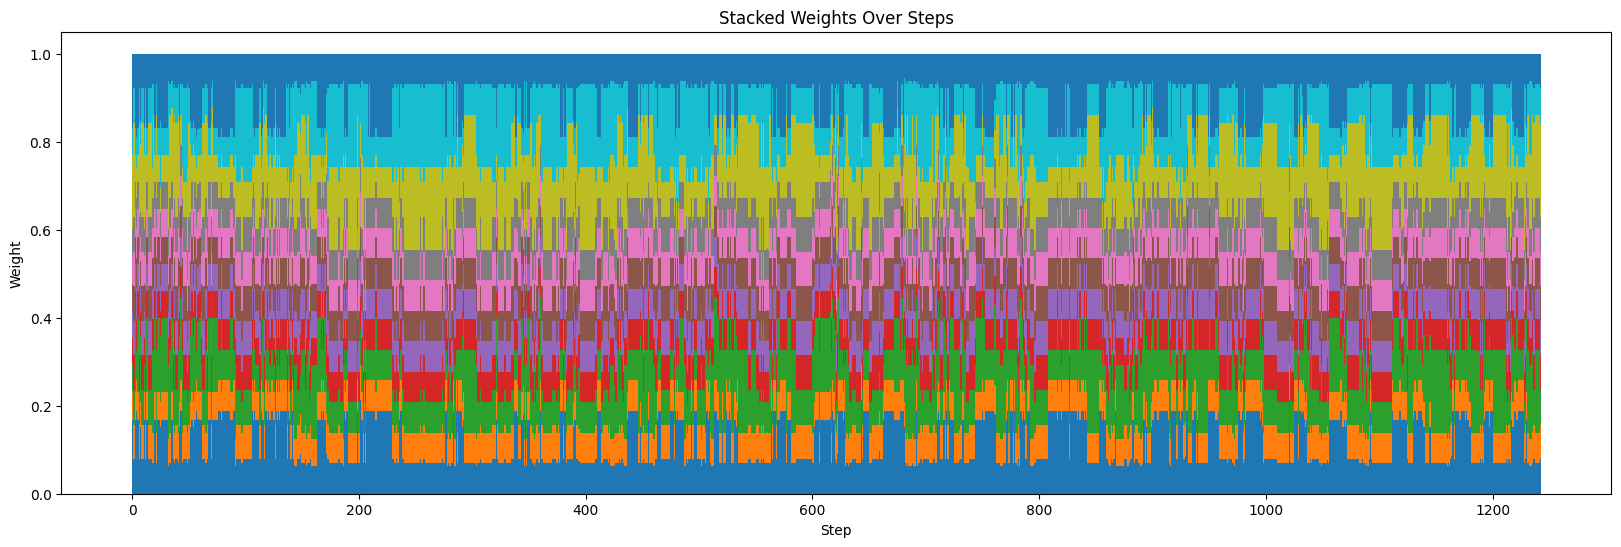

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# all_weights je tvoja premenná, napr. list alebo array (num_steps, num_assets)
num_steps = len(all_weights)
num_assets = len(all_weights[0])
weights_array = np.array(all_weights)

x = np.arange(num_steps)
bottom = np.zeros(num_steps)

# Zvýraznený širší graf
plt.figure(figsize=(20, 6))  # width=20, height=6

for i in range(num_assets):
    plt.bar(x, weights_array[:, i], bottom=bottom, width=1.0)
    bottom += weights_array[:, i]

plt.xlabel("Step")
plt.ylabel("Weight")
plt.title("Stacked Weights Over Steps")
plt.show()


In [3]:
import csv

with open("weights.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # header: date + Cash + tickers
    writer.writerow(["date", "Cash"] + tickers)

    # rows
    for date, weights in zip(dates, all_weights):
        writer.writerow(
            [date.strftime("%Y-%m-%d")] +
            [float(w) for w in weights]  # bez zaokrúhľovania
        )
